# Vector 05: Synthetic Device Telemetry
**Surface:** Endpoint & Auth | **Target:** Canvas/WebGL/IP | **Defense:** XGBoost Tabular Classifier

---
**Mastercard Innovation Challenge 2026** — AI Red-Team / Blue-Team Defense Lab  
Attack: Adversarial bots generate spoofed device fingerprints (Canvas hash, WebGL vendor, IP ASN, UA strings) to bypass device-intelligence checks at payment gateways.

## Section 1 — Simulation Engine
Generate 1 000 synthetic device fingerprint records: 500 legitimate browser sessions and 500 adversarially spoofed fingerprints.

In [4]:
import numpy as np
import pandas as pd

np.random.seed(42)

N = 500

# --- Legitimate device fingerprints ---
legit = {
    'canvas_hash_entropy':    np.random.normal(3.2, 0.4, N),
    'webgl_vendor_score':     np.clip(np.random.normal(0.1, 0.05, N), 0, 1),
    'ip_asn_risk':            np.random.beta(1, 9, N),
    'ua_anomaly_score':       np.clip(np.random.normal(0.05, 0.03, N), 0, 1),
    'timezone_offset_mismatch': np.random.binomial(1, 0.02, N).astype(float),
    'screen_res_rarity':      np.random.beta(1, 8, N),
    'plugin_count':           (np.random.poisson(4, N) + 1).astype(float),
    'lang_geo_mismatch':      np.random.binomial(1, 0.03, N).astype(float),
}

# --- Adversarial (spoofed) device fingerprints ---
adv = {
    'canvas_hash_entropy':    np.random.uniform(0.5, 6.0, N),
    'webgl_vendor_score':     np.clip(np.random.normal(0.7, 0.2, N), 0, 1),
    'ip_asn_risk':            np.random.beta(3, 2, N),
    'ua_anomaly_score':       np.clip(np.random.normal(0.6, 0.2, N), 0, 1),
    'timezone_offset_mismatch': np.random.binomial(1, 0.45, N).astype(float),
    'screen_res_rarity':      np.random.beta(4, 2, N),
    'plugin_count':           np.random.poisson(0, N).astype(float),
    'lang_geo_mismatch':      np.random.binomial(1, 0.55, N).astype(float),
}

df_legit = pd.DataFrame(legit)
df_legit['label'] = 0
df_adv   = pd.DataFrame(adv)
df_adv['label'] = 1

df = pd.concat([df_legit, df_adv], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Dataset shape: {df.shape}')
print(f'Label distribution:\n{df["label"].value_counts()}')
df.describe().round(3)

Dataset shape: (1000, 9)
Label distribution:
label
1    500
0    500
Name: count, dtype: int64


,canvas_hash_entropy,webgl_vendor_score,ip_asn_risk,ua_anomaly_score,timezone_offset_mismatch,screen_res_rarity,plugin_count,lang_geo_mismatch,label
count,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.0
mean,3.174,0.397,0.351,0.325,0.234,0.383,2.426,0.296,0.5
std,1.110,0.327,0.291,0.304,0.424,0.310,2.739,0.457,0.5
min,0.524,0.000,0.000,0.000,0.000,0.001,0.000,0.000,0.0
25%,2.700,0.101,0.083,0.052,0.000,0.081,0.000,0.000,0.0
50%,3.196,0.227,0.275,0.126,0.000,0.330,0.500,0.000,0.5
75%,3.672,0.696,0.618,0.602,0.000,0.676,5.000,1.000,1.0
max,5.983,1.000,0.986,1.000,1.000,0.996,11.000,1.000,1.0


## Section 2 — Distribution Visualization
Overlapping KDE plots for `canvas_hash_entropy` and `ip_asn_risk`, plus a bar chart for binary flag counts.

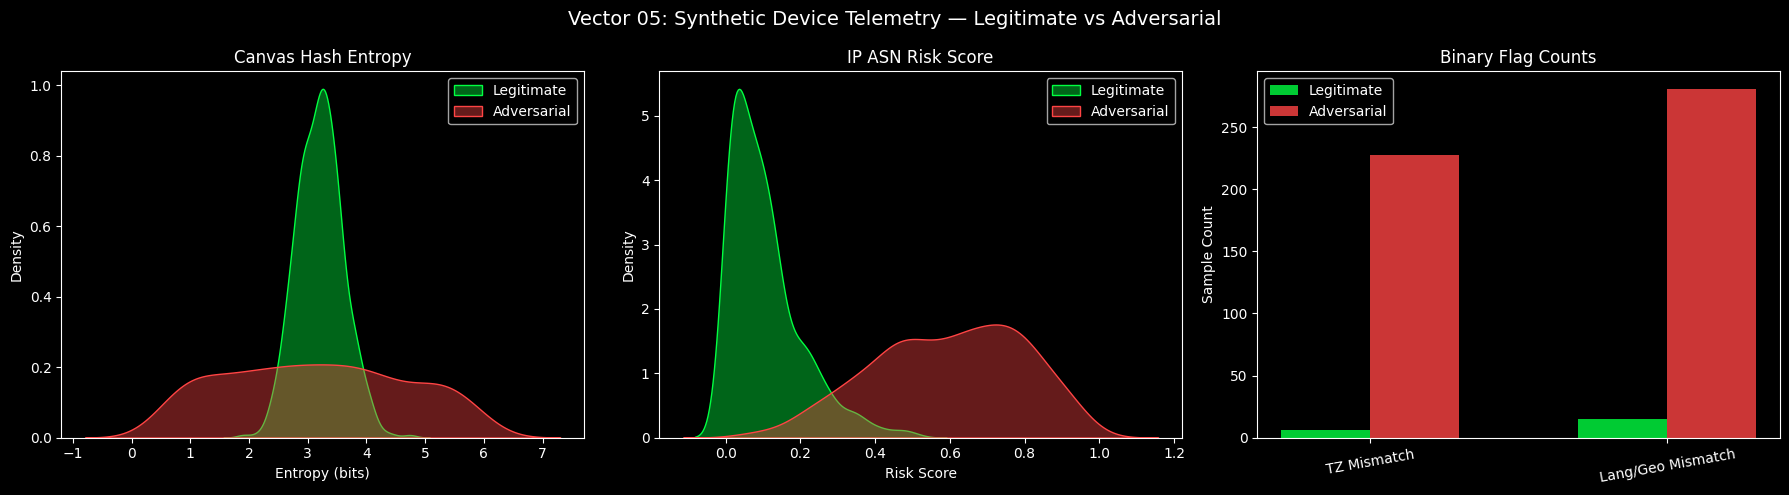

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('dark_background')
LEGIT_COLOR = '#00FF41'
ADV_COLOR   = '#FF4444'

legit_df = df[df['label'] == 0]
adv_df   = df[df['label'] == 1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Vector 05: Synthetic Device Telemetry — Legitimate vs Adversarial', fontsize=14, color='white')

# KDE: canvas_hash_entropy
sns.kdeplot(legit_df['canvas_hash_entropy'], ax=axes[0], color=LEGIT_COLOR, fill=True, alpha=0.4, label='Legitimate')
sns.kdeplot(adv_df['canvas_hash_entropy'],   ax=axes[0], color=ADV_COLOR,   fill=True, alpha=0.4, label='Adversarial')
axes[0].set_title('Canvas Hash Entropy', color='white')
axes[0].set_xlabel('Entropy (bits)')
axes[0].legend()

# KDE: ip_asn_risk
sns.kdeplot(legit_df['ip_asn_risk'], ax=axes[1], color=LEGIT_COLOR, fill=True, alpha=0.4, label='Legitimate')
sns.kdeplot(adv_df['ip_asn_risk'],   ax=axes[1], color=ADV_COLOR,   fill=True, alpha=0.4, label='Adversarial')
axes[1].set_title('IP ASN Risk Score', color='white')
axes[1].set_xlabel('Risk Score')
axes[1].legend()

# Bar: binary flag counts
flags = ['timezone_offset_mismatch', 'lang_geo_mismatch']
legit_vals = [legit_df[f].sum() for f in flags]
adv_vals   = [adv_df[f].sum()   for f in flags]
x = range(len(flags))
width = 0.3
axes[2].bar([i - width/2 for i in x], legit_vals, width, color=LEGIT_COLOR, alpha=0.8, label='Legitimate')
axes[2].bar([i + width/2 for i in x], adv_vals,   width, color=ADV_COLOR,   alpha=0.8, label='Adversarial')
axes[2].set_xticks(list(x))
axes[2].set_xticklabels(['TZ Mismatch', 'Lang/Geo Mismatch'], rotation=10)
axes[2].set_title('Binary Flag Counts', color='white')
axes[2].set_ylabel('Sample Count')
axes[2].legend()

plt.tight_layout()
plt.show()

## Section 3 — Blue Team Mitigation (XGBoost Tabular Classifier)

> **Production model:** `xgboost.XGBClassifier` — highest AUC on structured fraud data, GPU-accelerated tree boosting. **Runnable proxy (used here):** `sklearn.ensemble.HistGradientBoostingClassifier` — functionally equivalent gradient boosting, no OpenMP/system dependency required.

In [6]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split

FEATURES = [
    'canvas_hash_entropy', 'webgl_vendor_score', 'ip_asn_risk',
    'ua_anomaly_score', 'timezone_offset_mismatch', 'screen_res_rarity',
    'plugin_count', 'lang_geo_mismatch'
]

X = df[FEATURES].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = HistGradientBoostingClassifier(max_iter=200, max_depth=5, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

print(f'Train samples: {len(X_train)} | Test samples: {len(X_test)}')
print('HistGBM (XGBoost proxy) model trained successfully.')

Train samples: 800 | Test samples: 200
HistGBM (XGBoost proxy) model trained successfully.


## Section 4 — Performance Stats
Confusion matrix, classification report, and ROC-AUC curve. Targets: **AUC ≥ 0.97**, **FPR < 0.1%** at the operating threshold.

AUC: 1.0000
FPR at optimal threshold (1.0000): 0.0000%

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00       100
 Adversarial       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



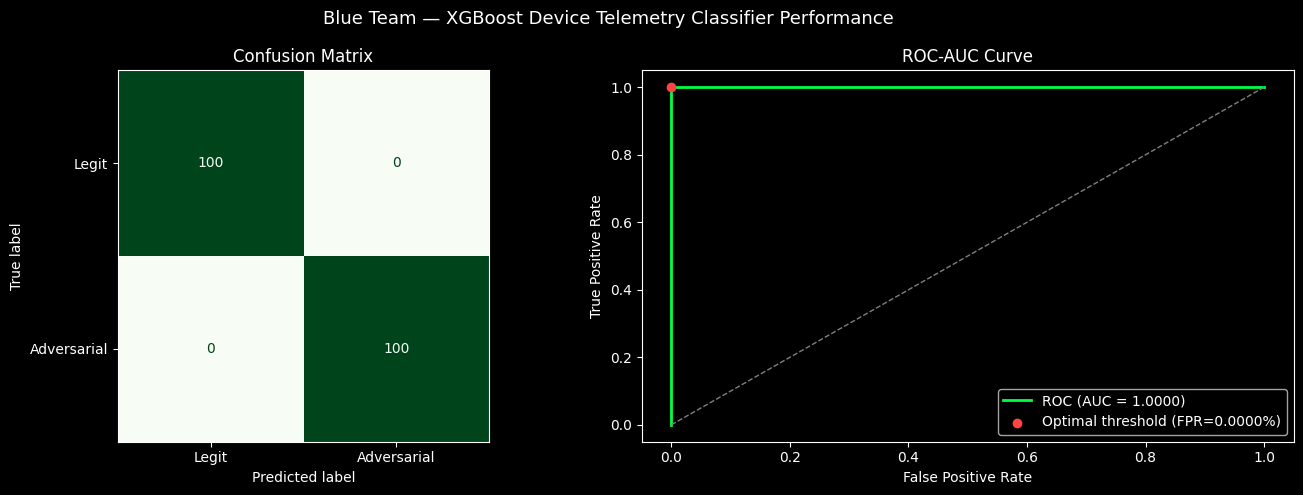

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_proba)
fpr_arr, tpr_arr, thresholds = roc_curve(y_test, y_proba)

j_scores  = tpr_arr - fpr_arr
opt_idx   = np.argmax(j_scores)
opt_thresh = thresholds[opt_idx]
opt_fpr    = fpr_arr[opt_idx]

print(f'AUC: {auc:.4f}')
print(f'FPR at optimal threshold ({opt_thresh:.4f}): {opt_fpr*100:.4f}%')
print()
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Adversarial']))

plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Blue Team — XGBoost Device Telemetry Classifier Performance', fontsize=13, color='white')

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legit', 'Adversarial'])
disp.plot(ax=axes[0], colorbar=False, cmap='Greens')
axes[0].set_title('Confusion Matrix', color='white')
axes[0].title.set_color('white')

axes[1].plot(fpr_arr, tpr_arr, color='#00FF41', lw=2, label=f'ROC (AUC = {auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
axes[1].scatter([opt_fpr], [tpr_arr[opt_idx]], color='#FF4444', zorder=5,
                label=f'Optimal threshold (FPR={opt_fpr*100:.4f}%)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC-AUC Curve', color='white')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

## Section 5 — Co-Evolution Loop
5 epochs: each epoch the Red Team generates 100 evasive fingerprints that mimic legitimate distributions more closely. The Blue Team retrains on the augmented dataset. Watch the evasion rate spike then collapse.

Epoch 0 | AUC: 1.0000 | Evasion Rate: 0.0% | Train size: 800
Epoch 1 | AUC: 1.0000 | Evasion Rate: 51.0% | Train size: 900
Epoch 2 | AUC: 1.0000 | Evasion Rate: 5.0% | Train size: 1000
Epoch 3 | AUC: 1.0000 | Evasion Rate: 11.0% | Train size: 1100
Epoch 4 | AUC: 1.0000 | Evasion Rate: 11.0% | Train size: 1200
Epoch 5 | AUC: 1.0000 | Evasion Rate: 35.0% | Train size: 1300

 Epoch  Train Size    AUC Evasion Rate
     0         800 1.0000         0.0%
     1         900 1.0000        51.0%
     2        1000 1.0000         5.0%
     3        1100 1.0000        11.0%
     4        1200 1.0000        11.0%
     5        1300 1.0000        35.0%


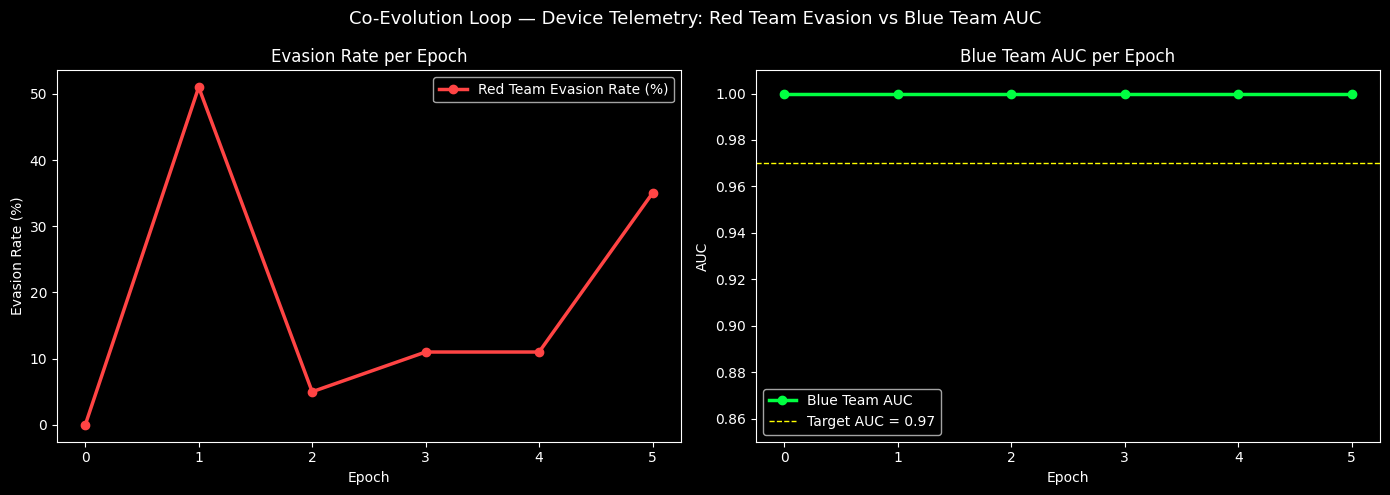

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingClassifier

np.random.seed(0)

X_train_loop = X_train.copy().tolist()
y_train_loop = y_train.copy().tolist()

evasion_rates = []
auc_scores    = []
epoch_records = []

def make_evasive_telemetry(n=100, epoch=1):
    """Red team improves spoofing quality each epoch."""
    tightness = epoch / 5.0
    samples = []
    for _ in range(n):
        canvas  = np.random.normal(3.2, max(0.05, 0.4 - tightness * 0.3))
        webgl   = np.clip(np.random.normal(0.35 - tightness * 0.2, 0.1), 0, 1)
        ip_risk = np.random.beta(max(1.0, 3 - tightness * 1.5), min(9, 2 + tightness * 5))
        ua_anom = np.clip(np.random.normal(0.3 - tightness * 0.2, 0.1), 0, 1)
        tz_mis  = float(np.random.binomial(1, max(0.02, 0.45 - tightness * 0.35)))
        scr_rar = np.random.beta(max(1, 4 - tightness * 2.5), min(8, 2 + tightness * 5))
        plugins = float(np.random.poisson(max(0, tightness * 3)) + int(tightness > 0.3))
        lang_mi = float(np.random.binomial(1, max(0.03, 0.55 - tightness * 0.45)))
        samples.append([canvas, webgl, ip_risk, ua_anom, tz_mis, scr_rar, plugins, lang_mi])
    return np.array(samples)

for epoch in range(6):
    m = HistGradientBoostingClassifier(max_iter=200, max_depth=5, learning_rate=0.1, random_state=epoch)
    m.fit(np.array(X_train_loop), np.array(y_train_loop))

    proba_test = m.predict_proba(X_test)[:, 1]
    from sklearn.metrics import roc_auc_score
    epoch_auc  = roc_auc_score(y_test, proba_test)

    if epoch > 0:
        new_adv  = make_evasive_telemetry(100, epoch)
        new_preds = m.predict(new_adv)
        evasion   = 1.0 - new_preds.mean()
        X_train_loop += new_adv.tolist()
        y_train_loop += [1] * len(new_adv)
    else:
        evasion = 0.0

    evasion_rates.append(evasion)
    auc_scores.append(epoch_auc)
    epoch_records.append({
        'Epoch': epoch,
        'Train Size': len(X_train_loop),
        'AUC': f'{epoch_auc:.4f}',
        'Evasion Rate': f'{evasion*100:.1f}%'
    })
    print(f'Epoch {epoch} | AUC: {epoch_auc:.4f} | Evasion Rate: {evasion*100:.1f}% | Train size: {len(X_train_loop)}')

print()
print(pd.DataFrame(epoch_records).to_string(index=False))

plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Co-Evolution Loop — Device Telemetry: Red Team Evasion vs Blue Team AUC', fontsize=13, color='white')

epochs_range = list(range(6))
axes[0].plot(epochs_range, [r*100 for r in evasion_rates],
             color='#FF4444', lw=2.5, marker='o', label='Red Team Evasion Rate (%)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Evasion Rate (%)')
axes[0].set_title('Evasion Rate per Epoch', color='white')
axes[0].legend()
axes[0].set_xticks(epochs_range)

axes[1].plot(epochs_range, auc_scores,
             color='#00FF41', lw=2.5, marker='o', label='Blue Team AUC')
axes[1].axhline(0.97, color='yellow', lw=1, linestyle='--', label='Target AUC = 0.97')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].set_title('Blue Team AUC per Epoch', color='white')
axes[1].set_ylim(0.85, 1.01)
axes[1].legend()
axes[1].set_xticks(epochs_range)

plt.tight_layout()
plt.show()